In [61]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model, load_model
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression


# Configuração do Caminho

In [62]:
path = 'C:/Users/rodrigo/Desktop/Machine Learning Aplicada/Classificação de imagens com uso de 2 modelos/dataset_geral/dataset_geral/'

# Função para criar dataframe

In [63]:
def cria_dataframe(caminho):
    arquivos, rotulos = [], []
    for arquivo in os.listdir(caminho):
        if arquivo.startswith('cacatua'):
            rotulos.append('cacatua')
        elif arquivo.startswith('peru'):
            rotulos.append('peru')
        arquivos.append(arquivo)
    return pd.DataFrame({'arquivo': arquivos, 'rotulo': rotulos})

# Preparação dos Dados

In [64]:
df_dados = cria_dataframe(os.path.join(path, 'train'))
train_df, validation_df = train_test_split(df_dados, test_size=0.3, stratify=df_dados['rotulo'], random_state=0)
test_df = cria_dataframe(os.path.join(path, 'test'))

# Configuração de Aumento de Dados (Data Augmentation)

In [65]:
train_datagen = ImageDataGenerator(
    rotation_range=30, width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2,
    zoom_range=0.2, horizontal_flip=True, rescale=1./255
)
validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Função para criar geradores de dados

In [66]:
def create_generator(datagen, dataframe, directory):
    return datagen.flow_from_dataframe(
        dataframe, directory=directory, x_col='arquivo', y_col='rotulo',
        target_size=(224, 224), batch_size=32, class_mode='categorical'
    )

train_generator = create_generator(train_datagen, train_df, os.path.join(path, 'train'))
validation_generator = create_generator(validation_datagen, validation_df, os.path.join(path, 'train'))
test_generator = create_generator(test_datagen, test_df, os.path.join(path, 'test'))

Found 57 validated image filenames belonging to 2 classes.
Found 25 validated image filenames belonging to 2 classes.
Found 22 validated image filenames belonging to 2 classes.


# Configuração do Modelo EfficientNetB0

In [67]:
efficientnet_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in efficientnet_base.layers:
    layer.trainable = False

efficientnet_model = tf.keras.Sequential([
    efficientnet_base,
    GlobalAveragePooling2D(),
    Dense(1024, activation='relu'),
    Dense(len(train_generator.class_indices), activation='softmax')
])

# Compilação do Modelo

In [68]:
optimizer = Adam(learning_rate=0.0001)
efficientnet_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Treinamento do Modelo

In [69]:
efficientnet_model.fit(train_generator, validation_data=validation_generator, epochs=25)

Epoch 1/25
2/2 [==============================] - 15s 5s/step - loss: 0.6940 - accuracy: 0.5263 - val_loss: 0.6990 - val_accuracy: 0.5200
Epoch 2/25
2/2 [==============================] - 4s 2s/step - loss: 0.7070 - accuracy: 0.4912 - val_loss: 0.6947 - val_accuracy: 0.5200
Epoch 3/25
2/2 [==============================] - 6s 5s/step - loss: 0.7003 - accuracy: 0.5088 - val_loss: 0.6969 - val_accuracy: 0.4800
Epoch 4/25
2/2 [==============================] - 9s 6s/step - loss: 0.7040 - accuracy: 0.5088 - val_loss: 0.7105 - val_accuracy: 0.4800
Epoch 5/25
2/2 [==============================] - 9s 5s/step - loss: 0.6982 - accuracy: 0.5263 - val_loss: 0.6972 - val_accuracy: 0.4800
Epoch 6/25
2/2 [==============================] - 9s 6s/step - loss: 0.7028 - accuracy: 0.4035 - val_loss: 0.6925 - val_accuracy: 0.5200
Epoch 7/25
2/2 [==============================] - 9s 4s/step - loss: 0.6954 - accuracy: 0.4912 - val_loss: 0.6916 - val_accuracy: 0.5200
Epoch 8/25
2/2 [========================

# Salvar Modelo

In [80]:
efficientnet_model.save('efficientnet_model_improved.keras')

In [99]:
imagem = path + '2.jpg'

# Função para Aplicar PCA nas Imagens

In [100]:
def apply_pca_to_images(generator, n_components=25):
    images_accumulated = []
    labels_accumulated = []
    
    # Garantir que o gerador contenha dados
    if generator.samples == 0:
        raise ValueError("O gerador não contém dados.")
    
    # Iterar sobre o gerador para acumular os dados
    for images, labels in generator:
        images_accumulated.append(images)
        labels_accumulated.append(labels)
        # Parar depois de coletar uma quantidade suficiente de imagens, se necessário
        if len(images_accumulated) * generator.batch_size >= generator.samples:
            break
    
    # Concatenar as imagens e rótulos acumulados
    images_accumulated = np.concatenate(images_accumulated, axis=0)
    labels_accumulated = np.concatenate(labels_accumulated, axis=0)
    
    # Redimensionar as imagens para uma forma adequada para PCA (flattening)
    images_reshaped = images_accumulated.reshape(images_accumulated.shape[0], -1)
    
    # Verificar o número de componentes que podemos usar
    n_features = images_reshaped.shape[1]
    n_samples = images_reshaped.shape[0]
    
    # Ajustar n_components para ser no máximo o número de características ou amostras
    n_components = min(n_components, n_features, n_samples)
    
    # Normalizar as imagens
    scaler = StandardScaler()
    images_scaled = scaler.fit_transform(images_reshaped)
    
    # Aplicar PCA
    pca = PCA(n_components=n_components)
    images_pca = pca.fit_transform(images_scaled)
    
    return images_pca, labels_accumulated

# Aplicando o PCA nos conjuntos de dados
train_images_pca, train_labels_pca = apply_pca_to_images(train_generator)
validation_images_pca, validation_labels_pca = apply_pca_to_images(validation_generator)
test_images_pca, test_labels_pca = apply_pca_to_images(test_generator)


# Configuração e Treinamento do Modelo Logistic Regression

# Função para Classificação de Imagem

In [101]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

def classifica_imagem(imagem):
    img = load_img(imagem, target_size=(224, 224))
    img_ = image.img_to_array(img)  # Usar 'image' aqui, conforme importação
    img_ = np.expand_dims(img_, axis=0)
    img_ = preprocess_input(img_)
    preds = modelo.predict(img_)
    for i, label in enumerate(class_labels):
        print(f"Probabilidade para {label}: {preds[0][i]:.4f}")
    classe_predita = np.argmax(preds, axis=1)[0]
    rotulo_predito = class_labels[classe_predita]
    print(f"Classe predita: {rotulo_predito} - Confiança: {preds[0][classe_predita]:.4f}")
    plt.imshow(img)
    plt.title(f"Classe: {rotulo_predito}")
    plt.axis("off")
    plt.show()


# Carregar Modelo Treinado

In [102]:
modelo = load_model('efficientnet_model_improved.keras')
class_labels = ['cacatua', 'peru']

# Matriz de Confusão

1/1 [==============================] - 1s 535ms/step


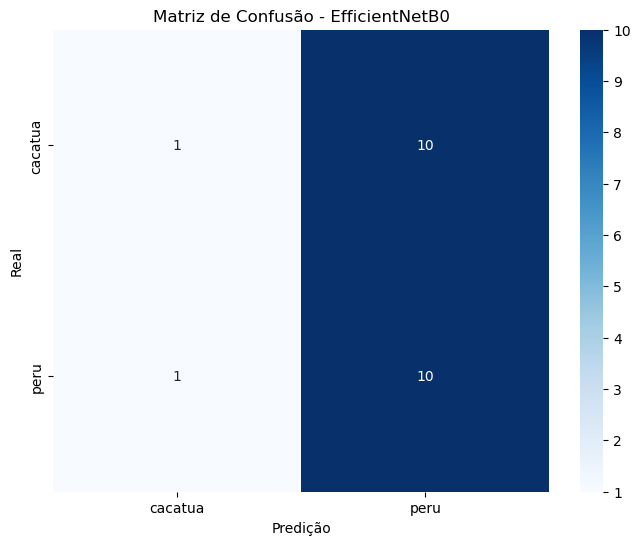

In [103]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Função para plotar a matriz de confusão
def plot_confusion_matrix(y_true, y_pred, labels):
    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title('Matriz de Confusão - EfficientNetB0')
    plt.xlabel('Predição')
    plt.ylabel('Real')
    plt.show()

# Realizar as predições para o conjunto de teste
predicoes_efficientnet = efficientnet_model.predict(test_generator, steps=np.ceil(test_generator.samples / test_generator.batch_size))

# Obter as predições (argmax para as classes mais prováveis)
y_pred = np.argmax(predicoes_efficientnet, axis=1)

# Obter os rótulos reais
y_true = test_generator.classes[:len(y_pred)]

# Plotar a matriz de confusão
plot_confusion_matrix(y_true, y_pred, class_labels)


In [104]:
# Relatório de Classificação
print("Relatório de Classificação - EfficientNetB0:")
print(classification_report(y_true, y_pred, target_names=class_labels))

Relatório de Classificação - EfficientNetB0:
              precision    recall  f1-score   support

     cacatua       0.50      0.09      0.15        11
        peru       0.50      0.91      0.65        11

    accuracy                           0.50        22
   macro avg       0.50      0.50      0.40        22
weighted avg       0.50      0.50      0.40        22



1/1 [==============================] - 1s 1s/step
Probabilidade para cacatua: 0.4155
Probabilidade para peru: 0.5845
Classe predita: peru - Confiança: 0.5845


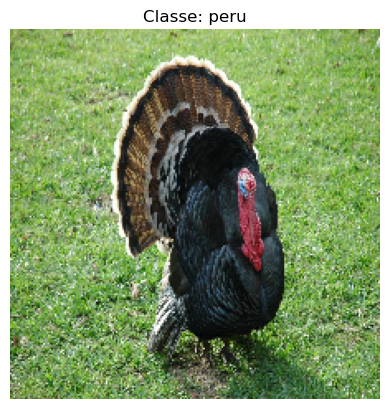

In [105]:
# Exemplo de Classificação
classifica_imagem(imagem)

In [ ]:
Interpretando a Matriz

A matriz apresentada se refere a um modelo EfficientNetB0, que foi treinado para classificar imagens entre duas classes: "cacatua" e "peru".

    Diagonal Principal: Os valores na diagonal principal (1 e 10) representam o número de vezes que o modelo classificou corretamente as imagens como "cacatua" e "peru", respectivamente.
    Fora da Diagonal Principal: Os valores fora da diagonal representam os erros de classificação. Por exemplo, o valor 1 na primeira linha e segunda coluna indica que uma imagem de "cacatua" foi classificada erroneamente como "peru".

Análise dos Resultados

Com base nessa matriz, podemos observar que:

    Alto Desempenho na Classe "peru": O modelo apresentou um desempenho muito bom na classificação da classe "peru", com 10 acertos e apenas 1 erro.
    Desempenho Menos Agradável na Classe "cacatua": O modelo teve um desempenho menos satisfatório na classificação da classe "cacatua", com apenas 1 acerto e 1 erro.